### Goal isolate the rooms

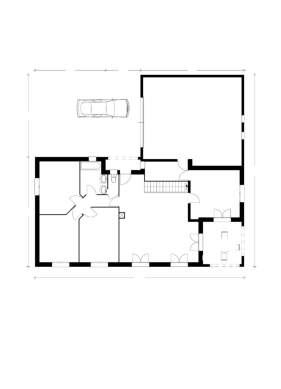

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

im = cv2.imread("../data/PNG/no_text/IIa_BA0710.png")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

plt.imshow(im)
plt.axis("off")
plt.show()

In [8]:
im.shape

(3508, 2480, 3)

### Preprocessing Pipeline

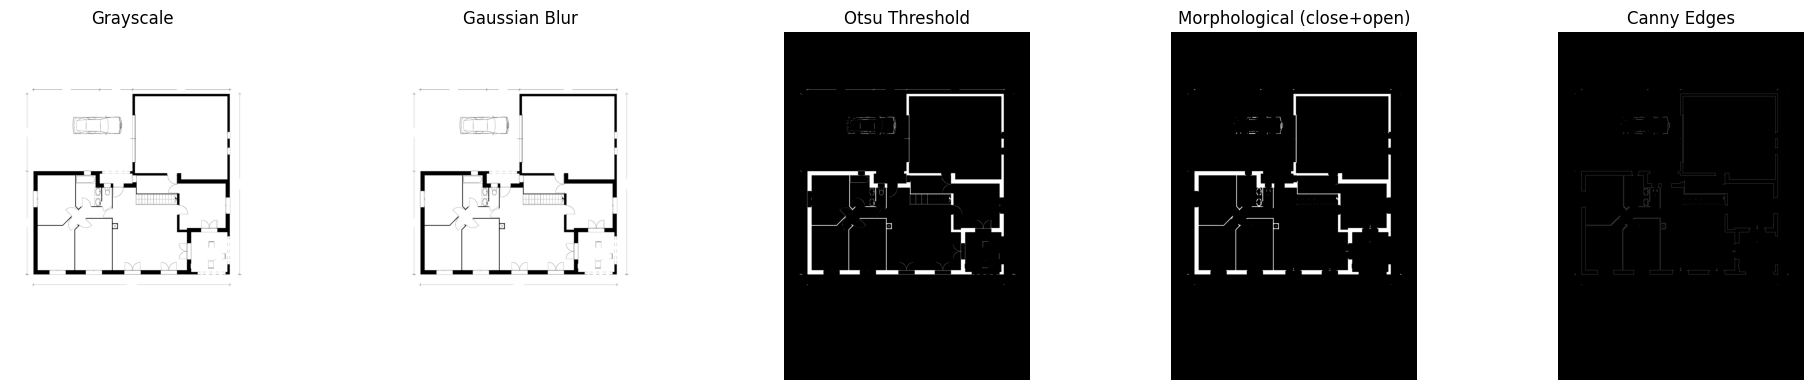

In [9]:
# 1. Grayscale
gray = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)

# 2. Blur — Gaussian to suppress noise before thresholding
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. Threshold — Otsu's binarization on the blurred image
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 4. Morphological ops — close small gaps in walls, remove speckle noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel, iterations=1)

# 5. Edge detection — Canny on the morphed binary
edges = cv2.Canny(morph, threshold1=50, threshold2=150)

stages = [
    (gray, "Grayscale"),
    (blurred, "Gaussian Blur"),
    (thresh, "Otsu Threshold"),
    (morph, "Morphological (close+open)"),
    (edges, "Canny Edges"),
]

fig, axes = plt.subplots(1, len(stages), figsize=(20, 4))
for ax, (img, title) in zip(axes, stages):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [10]:
import glob

images = glob.glob("../data/PNG/no_text/*")

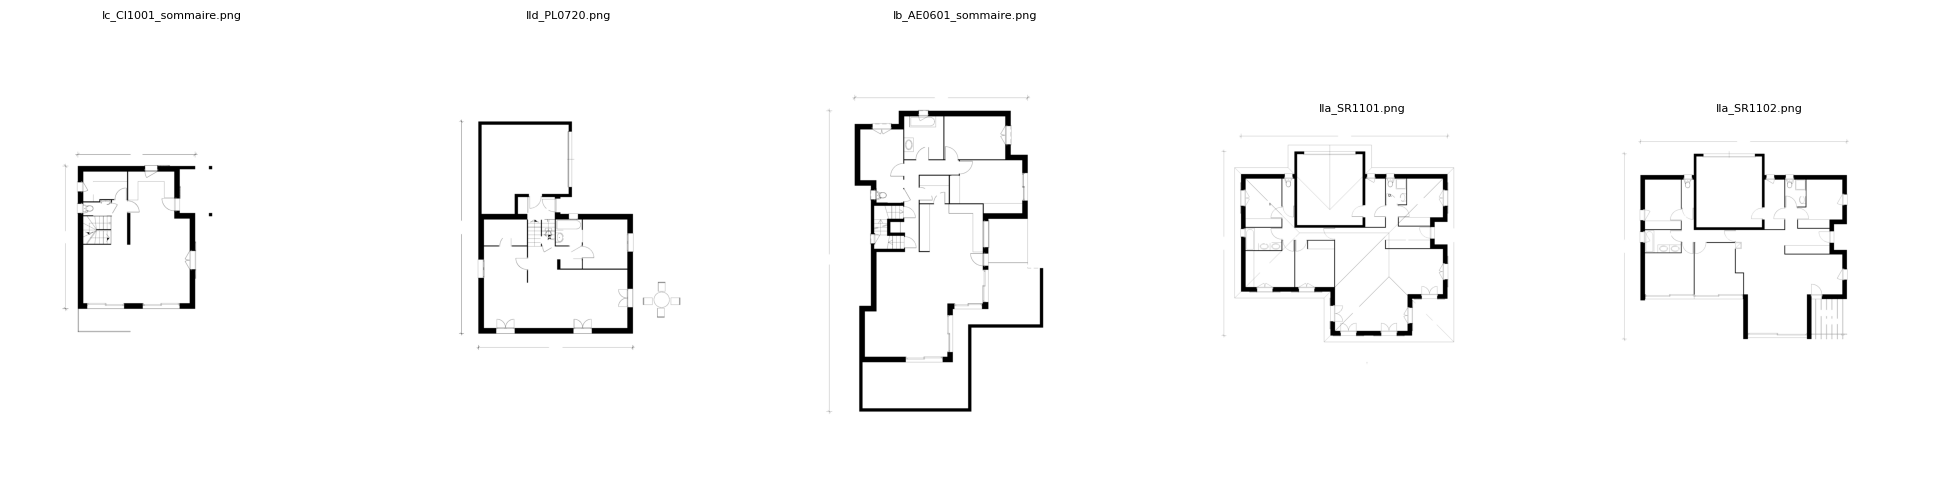

In [11]:
import random
from PIL import Image

import matplotlib.pyplot as plt

sample_paths = random.sample(images, 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, path in zip(axes, sample_paths):
    ax.imshow(Image.open(path))
    ax.axis("off")
    ax.set_title(path.split("/")[-1], fontsize=8)
plt.tight_layout()

In [12]:
import cv2
import os


def preprocessing_pipeline(im):
    gray = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (13, 13), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return thresh


for img_path in images:
    im = cv2.imread(img_path)
    thresh = preprocessing_pipeline(im)
    if not os.path.exists("../data/PNG/preprocessed"):
        os.makedirs("../data/PNG/preprocessed")
    cv2.imwrite(
        os.path.join("../data/PNG/preprocessed", os.path.basename(img_path)), thresh
    )

### Step 1 — Text Removal + Axis-Aligned Walls

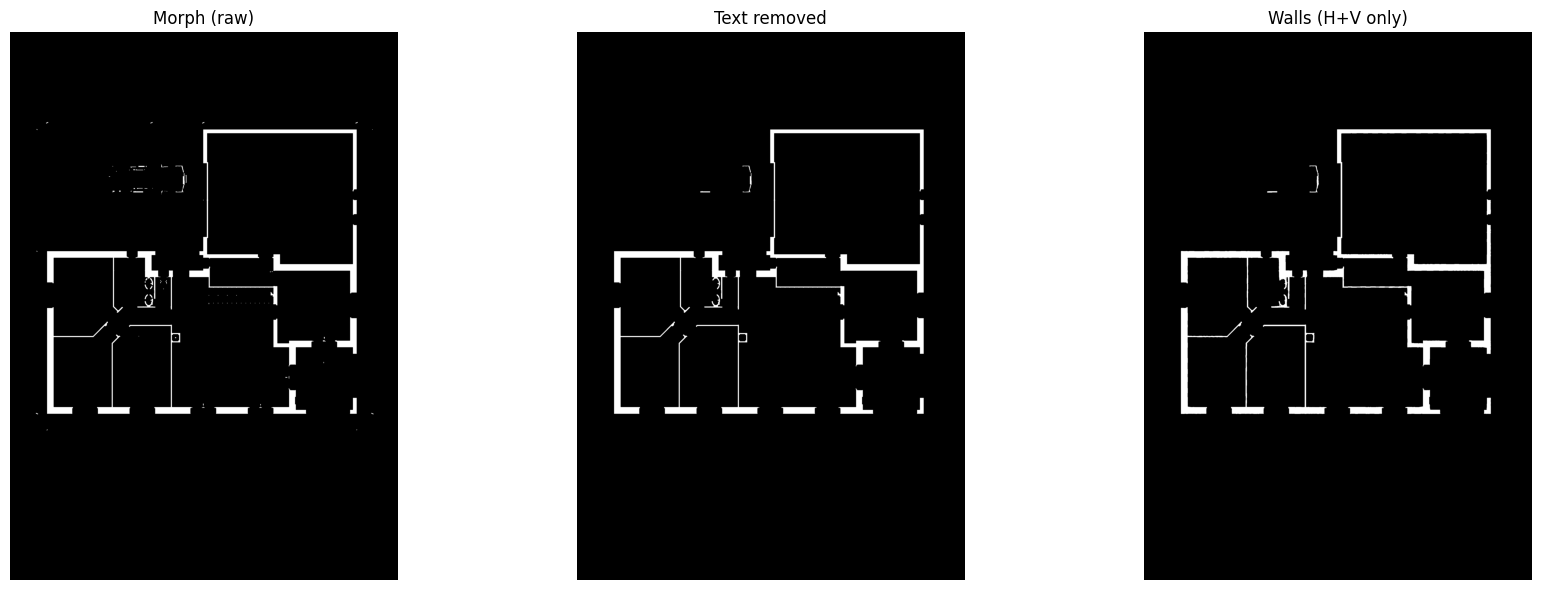

In [10]:
# ── Text removal: drop connected components smaller than a wall stroke ─────────
# Text blobs are small isolated regions; walls are large continuous structures.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
closed = cv2.morphologyEx(morph, cv2.MORPH_CLOSE, kernel, iterations=3)

num_cc, cc_labels, cc_stats, _ = cv2.connectedComponentsWithStats(
    closed, connectivity=8
)
walls_clean = np.zeros_like(closed)
for lbl in range(1, num_cc):
    if cc_stats[lbl, cv2.CC_STAT_AREA] >= 300:
        walls_clean[cc_labels == lbl] = 255

# ── Axis-aligned Hough: redraw only horizontal + vertical segments ─────────────
# Removes diagonal artifacts and bridges small wall gaps (maxLineGap).
lines = cv2.HoughLinesP(
    walls_clean, 1, np.pi / 180, 30, minLineLength=30, maxLineGap=20
)
wall_lines = np.zeros_like(walls_clean)
if lines is not None:
    for seg in lines:
        x1, y1, x2, y2 = seg[0]
        angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1))) % 180
        if angle < 12 or angle > 168 or abs(angle - 90) < 12:  # H or V
            cv2.line(wall_lines, (x1, y1), (x2, y2), 255, 2)

walls_final = cv2.bitwise_or(walls_clean, wall_lines)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(morph, cmap="gray")
axes[0].set_title("Morph (raw)")
axes[0].axis("off")
axes[1].imshow(walls_clean, cmap="gray")
axes[1].set_title("Text removed")
axes[1].axis("off")
axes[2].imshow(walls_final, cmap="gray")
axes[2].set_title("Walls (H+V only)")
axes[2].axis("off")
plt.tight_layout()
plt.show()

### Step 1b — Wall Equivalent Lines (WEL) Gap Closing
_Adapted from Zhu et al. (2013) "A new reconstruction method for 3D buildings from 2D vector floor plan"_

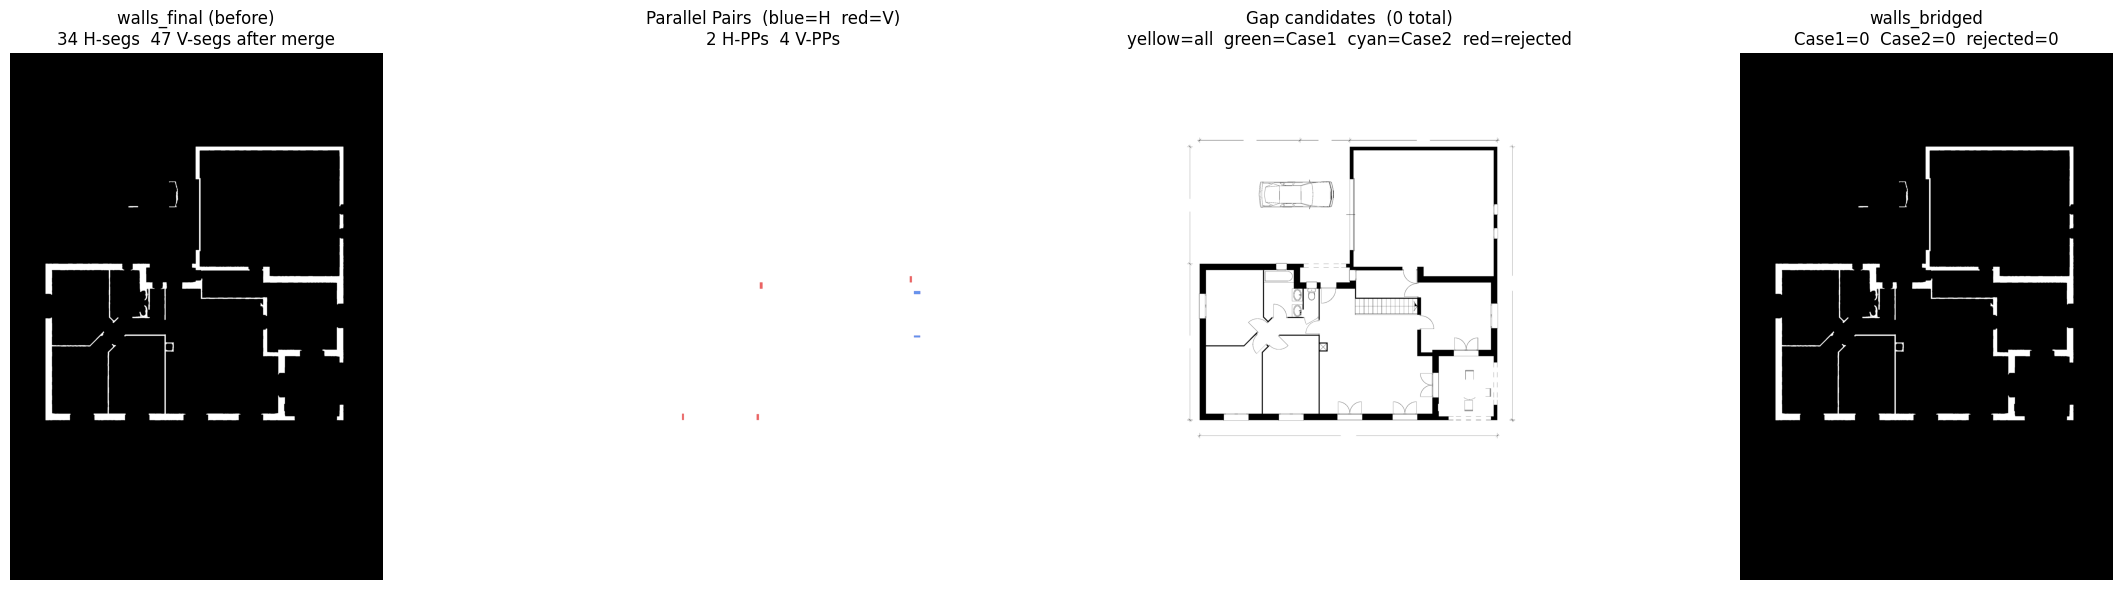

H-segments (after merge)  : 34
V-segments (after merge)  : 47
Parallel Pairs            : 6  (H=2  V=4)
Gap candidates            : 0
  Case 1 — collinear WEL  : 0
  Case 2 — offset WEL     : 0
  Rejected (perpendicular) : 0


In [11]:
# ── Parameters (tune these first) ────────────────────────────────────────────
max_wall_thickness = 20  # max px between two parallel segment axes to form a PP
max_gap_px = 40  # max distance between PP endpoints to bridge
axis_tolerance = 12  # max axis-offset (px) for Case 1 (collinear) WEL
min_wall_thickness = 6  # PP thinner than this is a dimension line → discard

# ── Imports ───────────────────────────────────────────────────────────────────
from scipy.spatial import KDTree

# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — Extract H/V wall segments via HoughLinesP (Zhu et al. §3.1)
#
#   Tighter params than Step 1: maxLineGap=8 intentionally small — gap-merging
#   is handled explicitly below so Hough doesn't bridge across door openings.
# ─────────────────────────────────────────────────────────────────────────────
walls_before = walls_final.copy()

raw_lines = cv2.HoughLinesP(
    walls_final, 1, np.pi / 180, 40, minLineLength=40, maxLineGap=8
)

h_segs = []  # horizontal: (x1, y1, x2, y2) with x1 <= x2, y1 ≈ y2
v_segs = []  # vertical:   (x1, y1, x2, y2) with y1 <= y2, x1 ≈ x2

if raw_lines is not None:
    for seg in raw_lines:
        x1, y1, x2, y2 = (int(v) for v in seg[0])
        angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1))) % 180
        if angle < 15 or angle > 165:  # horizontal
            if x1 > x2:
                x1, y1, x2, y2 = x2, y2, x1, y1
            h_segs.append((x1, y1, x2, y2))
        elif 75 < angle < 105:  # vertical
            if y1 > y2:
                x1, y1, x2, y2 = x2, y2, x1, y1
            v_segs.append((x1, y1, x2, y2))


# ─────────────────────────────────────────────────────────────────────────────
# Segment merging — fixes failure modes 1 and 2
#
#   FM1 (thick scan noise): HoughLinesP produces many overlapping detections
#        per wall face. Merge segments within 5px of the same axis.
#   FM2 (broken wall face): scan noise splits one face into 2-3 short pieces.
#        Merge collinear segments whose gap is < max_gap_px.
# ─────────────────────────────────────────────────────────────────────────────
def _merge_segments(segs, ori):
    """Merge near-parallel collinear segments into single long ones."""
    if not segs:
        return []
    items = []
    for x1, y1, x2, y2 in segs:
        ax = float((y1 + y2) / 2) if ori == "H" else float((x1 + x2) / 2)
        ps = float(x1 if ori == "H" else y1)
        pe = float(x2 if ori == "H" else y2)
        items.append((ax, ps, pe))
    items.sort(key=lambda t: (t[0], t[1]))

    merged = []
    cur_ax, cur_s, cur_e = items[0]
    for ax, s, e in items[1:]:
        if abs(ax - cur_ax) <= 5.0 and s <= cur_e + max_gap_px:
            cur_ax = (cur_ax + ax) / 2.0  # average axis to handle slight tilt
            cur_e = max(cur_e, e)
        else:
            merged.append((cur_ax, cur_s, cur_e))
            cur_ax, cur_s, cur_e = ax, s, e
    merged.append((cur_ax, cur_s, cur_e))

    result = []
    for ax, s, e in merged:
        if ori == "H":
            result.append((int(s), int(ax), int(e), int(ax)))
        else:
            result.append((int(ax), int(s), int(ax), int(e)))
    return result


h_segs = _merge_segments(h_segs, "H")
v_segs = _merge_segments(v_segs, "V")


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — Parallel Pair (PP) detection (Zhu et al. §3.2)
#
#   A PP = two nearly-parallel segments representing the inner/outer faces of
#   one wall. Conditions: same orientation + axis gap < max_wall_thickness +
#   overlap along the wall axis > 50%.
#
#   FM3 (false PP from dimension lines): dimension lines are always thinner
#        than real walls. Discard any PP with thickness < min_wall_thickness.
#   Spec: groups with > 2 matching segments are ambiguous → discard them.
# ─────────────────────────────────────────────────────────────────────────────
def _make_pp(s1, s2, ori):
    """Build a PP dict from two matched segments."""
    if ori == "H":
        y1 = (s1[1] + s1[3]) / 2.0
        y2 = (s2[1] + s2[3]) / 2.0
        flo, fhi = sorted([y1, y2])
        axis = (flo + fhi) / 2.0
        thick = fhi - flo
        xs = max(min(s1[0], s1[2]), min(s2[0], s2[2]))  # overlap start X
        xe = min(max(s1[0], s1[2]), max(s2[0], s2[2]))  # overlap end X
        if xs >= xe:  # degenerate → use union
            xs = min(min(s1[0], s1[2]), min(s2[0], s2[2]))
            xe = max(max(s1[0], s1[2]), max(s2[0], s2[2]))
        return dict(
            ori="H",
            axis=axis,
            thick=thick,
            face_lo=flo,
            face_hi=fhi,
            proj_s=float(xs),
            proj_e=float(xe),
            ep_s=(float(xs), axis),
            ep_e=(float(xe), axis),
        )
    else:
        x1 = (s1[0] + s1[2]) / 2.0
        x2 = (s2[0] + s2[2]) / 2.0
        flo, fhi = sorted([x1, x2])
        axis = (flo + fhi) / 2.0
        thick = fhi - flo
        ys = max(min(s1[1], s1[3]), min(s2[1], s2[3]))  # overlap start Y
        ye = min(max(s1[1], s1[3]), max(s2[1], s2[3]))  # overlap end Y
        if ys >= ye:
            ys = min(min(s1[1], s1[3]), min(s2[1], s2[3]))
            ye = max(max(s1[1], s1[3]), max(s2[1], s2[3]))
        return dict(
            ori="V",
            axis=axis,
            thick=thick,
            face_lo=flo,
            face_hi=fhi,
            proj_s=float(ys),
            proj_e=float(ye),
            ep_s=(axis, float(ys)),
            ep_e=(axis, float(ye)),
        )


def _detect_pps(segs, ori):
    n = len(segs)
    if n < 2:
        return []
    partners = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(i + 1, n):
            if ori == "H":
                ai = (segs[i][1] + segs[i][3]) / 2.0
                aj = (segs[j][1] + segs[j][3]) / 2.0
                si, ei = min(segs[i][0], segs[i][2]), max(segs[i][0], segs[i][2])
                sj, ej = min(segs[j][0], segs[j][2]), max(segs[j][0], segs[j][2])
            else:
                ai = (segs[i][0] + segs[i][2]) / 2.0
                aj = (segs[j][0] + segs[j][2]) / 2.0
                si, ei = min(segs[i][1], segs[i][3]), max(segs[i][1], segs[i][3])
                sj, ej = min(segs[j][1], segs[j][3]), max(segs[j][1], segs[j][3])
            overlap = max(0.0, min(ei, ej) - max(si, sj))
            len_max = max(ei - si, ej - sj, 1.0)
            if abs(ai - aj) < max_wall_thickness and overlap / len_max > 0.5:
                partners[i].append(j)
                partners[j].append(i)
    pps_out = []
    formed = set()
    for i in range(n):
        if len(partners[i]) == 1:  # exactly one partner → clean pair
            j = partners[i][0]
            if len(partners[j]) == 1:
                key = (min(i, j), max(i, j))
                if key not in formed:
                    formed.add(key)
                    pp = _make_pp(segs[i], segs[j], ori)
                    if pp["thick"] >= min_wall_thickness:  # FM3 guard
                        pps_out.append(pp)
    return pps_out


pps = _detect_pps(h_segs, "H") + _detect_pps(v_segs, "V")


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 3 — Gap candidates: nearby endpoints from different PPs (Zhu et al. §3.3)
#
#   Each PP contributes two endpoints (start and end of its axis projection).
#   KDTree finds pairs within max_gap_px; same-PP pairs are discarded.
#
#   FM4 (endpoint imprecision): HoughLinesP endpoints can be off by ±5-8px.
#        For each candidate, also compute the projected distance — the distance
#        from ep_a to the nearest point on pp_b's axis segment, and vice versa.
#        Accept if min(direct, proj_a→b, proj_b→a) < max_gap_px.
# ─────────────────────────────────────────────────────────────────────────────
def _proj_dist(ep, pp):
    """Distance from point ep=(x,y) to the nearest point on pp's axis segment."""
    if pp["ori"] == "H":
        xc = float(np.clip(ep[0], pp["proj_s"], pp["proj_e"]))
        return np.hypot(ep[0] - xc, ep[1] - pp["axis"])
    else:
        yc = float(np.clip(ep[1], pp["proj_s"], pp["proj_e"]))
        return np.hypot(ep[0] - pp["axis"], ep[1] - yc)


# Endpoint registry: two entries per PP (start side, end side)
ep_list = []  # (x, y, pp_idx, side)
for pi, pp in enumerate(pps):
    ep_list.append((*pp["ep_s"], pi, "s"))
    ep_list.append((*pp["ep_e"], pi, "e"))

candidates = []  # list of (ia, ib) index pairs into ep_list
if len(ep_list) >= 2:
    ep_xy = np.array([(e[0], e[1]) for e in ep_list], dtype=float)
    for ia, ib in KDTree(ep_xy).query_pairs(max_gap_px):
        pia, pib = ep_list[ia][2], ep_list[ib][2]
        if pia == pib:
            continue  # same PP — skip
        ea, eb = ep_list[ia][:2], ep_list[ib][:2]
        ppa, ppb = pps[pia], pps[pib]
        direct = np.hypot(ea[0] - eb[0], ea[1] - eb[1])
        eff = min(direct, _proj_dist(ea, ppb), _proj_dist(eb, ppa))  # FM4
        if eff < max_gap_px:
            candidates.append((ia, ib))

# ─────────────────────────────────────────────────────────────────────────────
# PHASE 4 — Classify candidates and draw WELs (Zhu et al. §3.4)
#
#   Priority: Case 1 is checked first. If it fails, check Case 2.
#   If neither matches (perpendicular walls — Cases 3/4), skip.
#
#   Case 1 (collinear): same orientation, |axis_a − axis_b| ≤ axis_tolerance
#           WEL: extend both wall faces straight across the gap.
#           This is the dominant case (~80% of doors on rectilinear plans).
#
#   Case 2 (offset):    same orientation, |axis_a − axis_b| > axis_tolerance
#           WEL: draw two parallel lines perpendicular to the wall orientation,
#           passing through the center of the gap bounding box.
#
#   Both wall faces are drawn (not a centerline) to preserve the double-wall
#   structure that prevents flood-fill leakage through thin bridges.
#
#   Cases 3/4 (perpendicular walls) — TODO: out of scope for rectilinear plans.
# ─────────────────────────────────────────────────────────────────────────────
walls_bridged = walls_final.copy()
LW = 2  # WEL stroke width (px)

case1_eps = []  # (ea, eb) — for visualisation
case2_eps = []
rejected_eps = []


def _ipt(x, y):
    return (int(round(x)), int(round(y)))


for ia, ib in candidates:
    ea = ep_list[ia][:2]
    eb = ep_list[ib][:2]
    ppa = pps[ep_list[ia][2]]
    ppb = pps[ep_list[ib][2]]

    if ppa["ori"] != ppb["ori"]:  # Cases 3/4 — perpendicular, skip for now
        rejected_eps.append((ea, eb))
        continue

    axis_diff = abs(ppa["axis"] - ppb["axis"])
    mean_thick = max(2.0, (ppa["thick"] + ppb["thick"]) / 2.0)

    # ── Case 1: collinear — extend both faces straight across ─────────────────
    if axis_diff <= axis_tolerance:
        if ppa["ori"] == "H":
            cv2.line(
                walls_bridged,
                _ipt(ea[0], ppa["face_lo"]),
                _ipt(eb[0], ppb["face_lo"]),
                255,
                LW,
            )
            cv2.line(
                walls_bridged,
                _ipt(ea[0], ppa["face_hi"]),
                _ipt(eb[0], ppb["face_hi"]),
                255,
                LW,
            )
        else:
            cv2.line(
                walls_bridged,
                _ipt(ppa["face_lo"], ea[1]),
                _ipt(ppb["face_lo"], eb[1]),
                255,
                LW,
            )
            cv2.line(
                walls_bridged,
                _ipt(ppa["face_hi"], ea[1]),
                _ipt(ppb["face_hi"], eb[1]),
                255,
                LW,
            )
        case1_eps.append((ea, eb))

    # ── Case 2: offset — centered perpendicular bridge ────────────────────────
    else:
        half = mean_thick / 2.0
        if ppa["ori"] == "H":
            cx = (ea[0] + eb[0]) / 2.0
            ymin = min(ppa["face_lo"], ppb["face_lo"])
            ymax = max(ppa["face_hi"], ppb["face_hi"])
            cv2.line(
                walls_bridged, _ipt(cx - half, ymin), _ipt(cx - half, ymax), 255, LW
            )
            cv2.line(
                walls_bridged, _ipt(cx + half, ymin), _ipt(cx + half, ymax), 255, LW
            )
        else:
            cy = (ea[1] + eb[1]) / 2.0
            xmin = min(ppa["face_lo"], ppb["face_lo"])
            xmax = max(ppa["face_hi"], ppb["face_hi"])
            cv2.line(
                walls_bridged, _ipt(xmin, cy - half), _ipt(xmax, cy - half), 255, LW
            )
            cv2.line(
                walls_bridged, _ipt(xmin, cy + half), _ipt(xmax, cy + half), 255, LW
            )
        case2_eps.append((ea, eb))

# ─────────────────────────────────────────────────────────────────────────────
# Visualisation — 4 panels
# ─────────────────────────────────────────────────────────────────────────────
h_img, w_img = walls_final.shape

# Panel 2: detected PPs on white canvas — H-PPs blue, V-PPs red (RGB)
pp_canvas = np.full((h_img, w_img, 3), 255, dtype=np.uint8)
for pp in pps:
    if pp["ori"] == "H":
        x1, x2 = int(pp["proj_s"]), int(pp["proj_e"])
        y1, y2 = int(pp["face_lo"]), int(pp["face_hi"])
        cv2.rectangle(pp_canvas, (x1, y1), (x2, y2), (100, 149, 237), -1)  # blue fill
        cv2.rectangle(pp_canvas, (x1, y1), (x2, y2), (25, 25, 200), 1)  # blue border
    else:
        x1, x2 = int(pp["face_lo"]), int(pp["face_hi"])
        y1, y2 = int(pp["proj_s"]), int(pp["proj_e"])
        cv2.rectangle(pp_canvas, (x1, y1), (x2, y2), (237, 100, 100), -1)  # red fill
        cv2.rectangle(pp_canvas, (x1, y1), (x2, y2), (200, 25, 25), 1)  # red border

# Panel 3: gap candidates overlaid on original image
p3 = im.copy()
for ia, ib in candidates:  # yellow: all candidates
    ea, eb = ep_list[ia][:2], ep_list[ib][:2]
    cv2.line(p3, _ipt(*ea), _ipt(*eb), (255, 255, 0), 1)
for ea, eb in rejected_eps:  # red: rejected
    cv2.line(p3, _ipt(*ea), _ipt(*eb), (220, 30, 30), 1)
for ea, eb in case2_eps:  # cyan: Case 2
    cv2.line(p3, _ipt(*ea), _ipt(*eb), (0, 210, 210), 2)
for ea, eb in case1_eps:  # green: Case 1
    cv2.line(p3, _ipt(*ea), _ipt(*eb), (0, 200, 0), 2)

n_hpps = sum(p["ori"] == "H" for p in pps)
n_vpps = len(pps) - n_hpps

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(walls_before, cmap="gray")
axes[0].set_title(
    f"walls_final (before)\n{len(h_segs)} H-segs  {len(v_segs)} V-segs after merge"
)
axes[0].axis("off")

axes[1].imshow(pp_canvas)
axes[1].set_title(f"Parallel Pairs  (blue=H  red=V)\n{n_hpps} H-PPs  {n_vpps} V-PPs")
axes[1].axis("off")

axes[2].imshow(p3)
axes[2].set_title(
    f"Gap candidates  ({len(candidates)} total)\nyellow=all  green=Case1  cyan=Case2  red=rejected"
)
axes[2].axis("off")

axes[3].imshow(walls_bridged, cmap="gray")
axes[3].set_title(
    f"walls_bridged\nCase1={len(case1_eps)}  Case2={len(case2_eps)}  rejected={len(rejected_eps)}"
)
axes[3].axis("off")

plt.tight_layout()
plt.show()

print(f"H-segments (after merge)  : {len(h_segs)}")
print(f"V-segments (after merge)  : {len(v_segs)}")
print(f"Parallel Pairs            : {len(pps)}  (H={n_hpps}  V={n_vpps})")
print(f"Gap candidates            : {len(candidates)}")
print(f"  Case 1 — collinear WEL  : {len(case1_eps)}")
print(f"  Case 2 — offset WEL     : {len(case2_eps)}")
print(f"  Rejected (perpendicular) : {len(rejected_eps)}")

### Step 2 — Top-Left Scan → Trace Walls → Detect Corners → Find Rooms

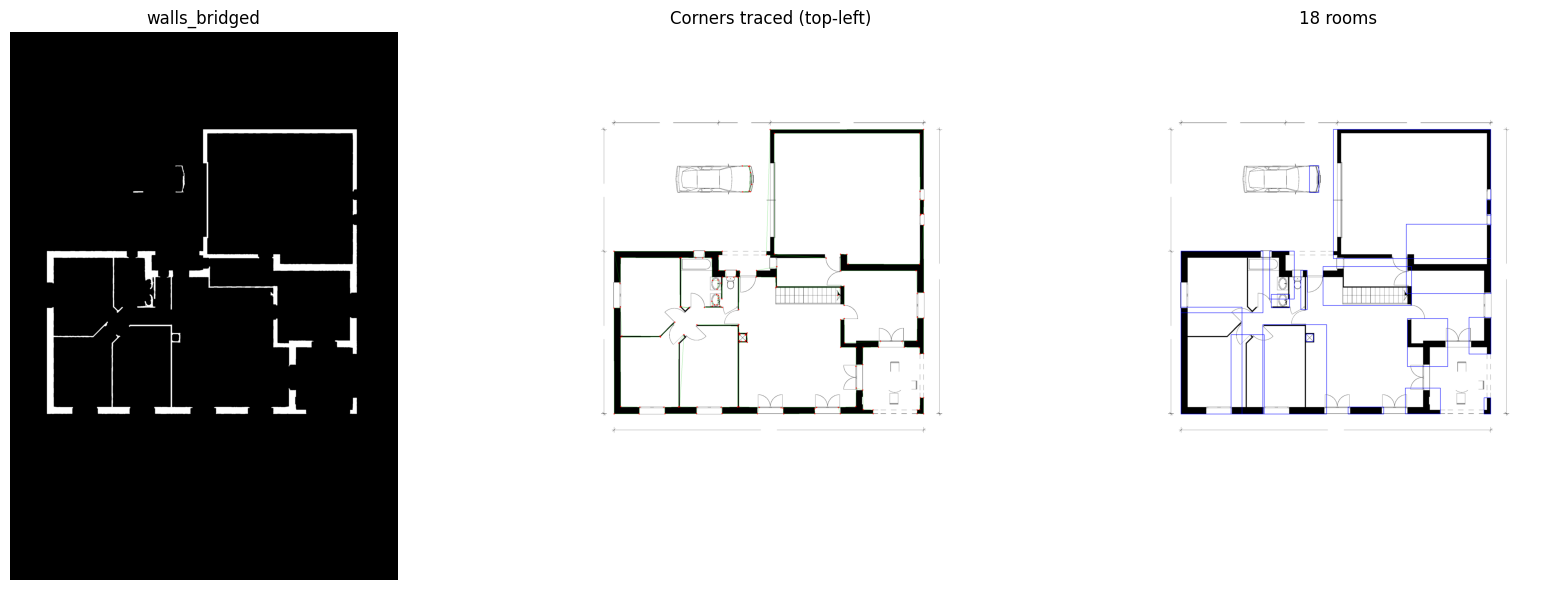

Rooms found: 18
  Room 1: origin=(1304,2400)  size=228×45 px
  Room 2: origin=(2173,2341)  size=43×104 px
  Room 3: origin=(1670,2279)  size=224×165 px
  Room 4: origin=(556,1937)  size=212×508 px
  Room 5: origin=(759,1873)  size=408×572 px
  Room 6: origin=(1035,1933)  size=47×48 px
  Room 7: origin=(1683,1834)  size=258×307 px
  Room 8: origin=(2077,1826)  size=140×235 px
  Room 9: origin=(236,1761)  size=390×684 px
  Room 10: origin=(813,1679)  size=117×86 px
  Room 11: origin=(1002,1525)  size=41×252 px
  Room 12: origin=(1144,1501)  size=566×249 px
  Room 13: origin=(803,1402)  size=157×307 px
  Room 14: origin=(236,1402)  size=524×395 px
  Room 15: origin=(1676,1230)  size=541×444 px
  Room 16: origin=(2191,1071)  size=26×101 px
  Room 17: origin=(1057,855)  size=60×172 px
  Room 18: origin=(1210,623)  size=1006×827 px


In [ ]:
# findContours scans the image in row-major order (top-left → right → down),
# traces each wall boundary pixel-by-pixel, and chains corner points.
# TC89_KCOS is a chain-approximation that preserves geometric corners.
contours, hierarchy = cv2.findContours(
    walls_bridged, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_TC89_KCOS
)

img_area = im.shape[0] * im.shape[1]
MIN_AREA = 800
MAX_AREA = img_area * 0.45
MIN_CORNERS = 4  # a room needs at least 4 corners

boxes = []
corner_vis = im.copy()

if hierarchy is not None:
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if not (MIN_AREA < area < MAX_AREA):
            continue

        # Approximate to a polygon — epsilon controls corner sensitivity
        eps = 0.015 * cv2.arcLength(cnt, True)
        poly = cv2.approxPolyDP(cnt, eps, True)

        if len(poly) < MIN_CORNERS:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        # Skip very elongated shapes (single wall segments, not rooms)
        if max(w, h) / (min(w, h) + 1) > 12:
            continue

        boxes.append((x, y, w, h))

        # Visualise traced path and detected corners
        cv2.drawContours(corner_vis, [poly], -1, (0, 200, 0), 1)
        for pt in poly:
            cv2.circle(corner_vis, tuple(pt[0]), 4, (255, 0, 0), -1)

result = im.copy()
for x, y, w, h in boxes:
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 0, 255), 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(walls_bridged, cmap="gray")
axes[0].set_title("walls_bridged")
axes[0].axis("off")
axes[1].imshow(corner_vis)
axes[1].set_title("Corners traced (top-left)")
axes[1].axis("off")
axes[2].imshow(result)
axes[2].set_title(f"{len(boxes)} rooms")
axes[2].axis("off")
plt.tight_layout()
plt.show()

print(f"Rooms found: {len(boxes)}")
for i, (x, y, w, h) in enumerate(boxes):
    print(f"  Room {i+1}: origin=({x},{y})  size={w}×{h} px")